In [1]:
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import xarray as xr

In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
N = 20   # number of processes to sample (i.e. how many different CDFs do we get)
K = 10   # number of points in the stick-breaking process (upper limit on number of parts/clusters)
#assert K >= N

alpha = 0.5
P0 = sp.stats.norm

We draw and plot samples from the stick-breaking process.  $w$ is then a set of samples which add up to 1, by construction.

In [4]:
beta = sp.stats.beta.rvs(1, alpha, size=(N, K))
w = np.empty_like(beta)
w[:, 0] = beta[:, 0]
w[:, 1:] = beta[:, 1:] * (1 - beta[:, :-1]).cumprod(axis=1)

In [5]:
w.sum(axis=1)

array([0.99991698, 0.99999819, 1.        , 0.99998952, 0.9999989 ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.99999613, 1.        , 1.        , 0.99999997,
       0.9999959 , 0.99999995, 0.9999994 , 0.99999939, 1.        ])

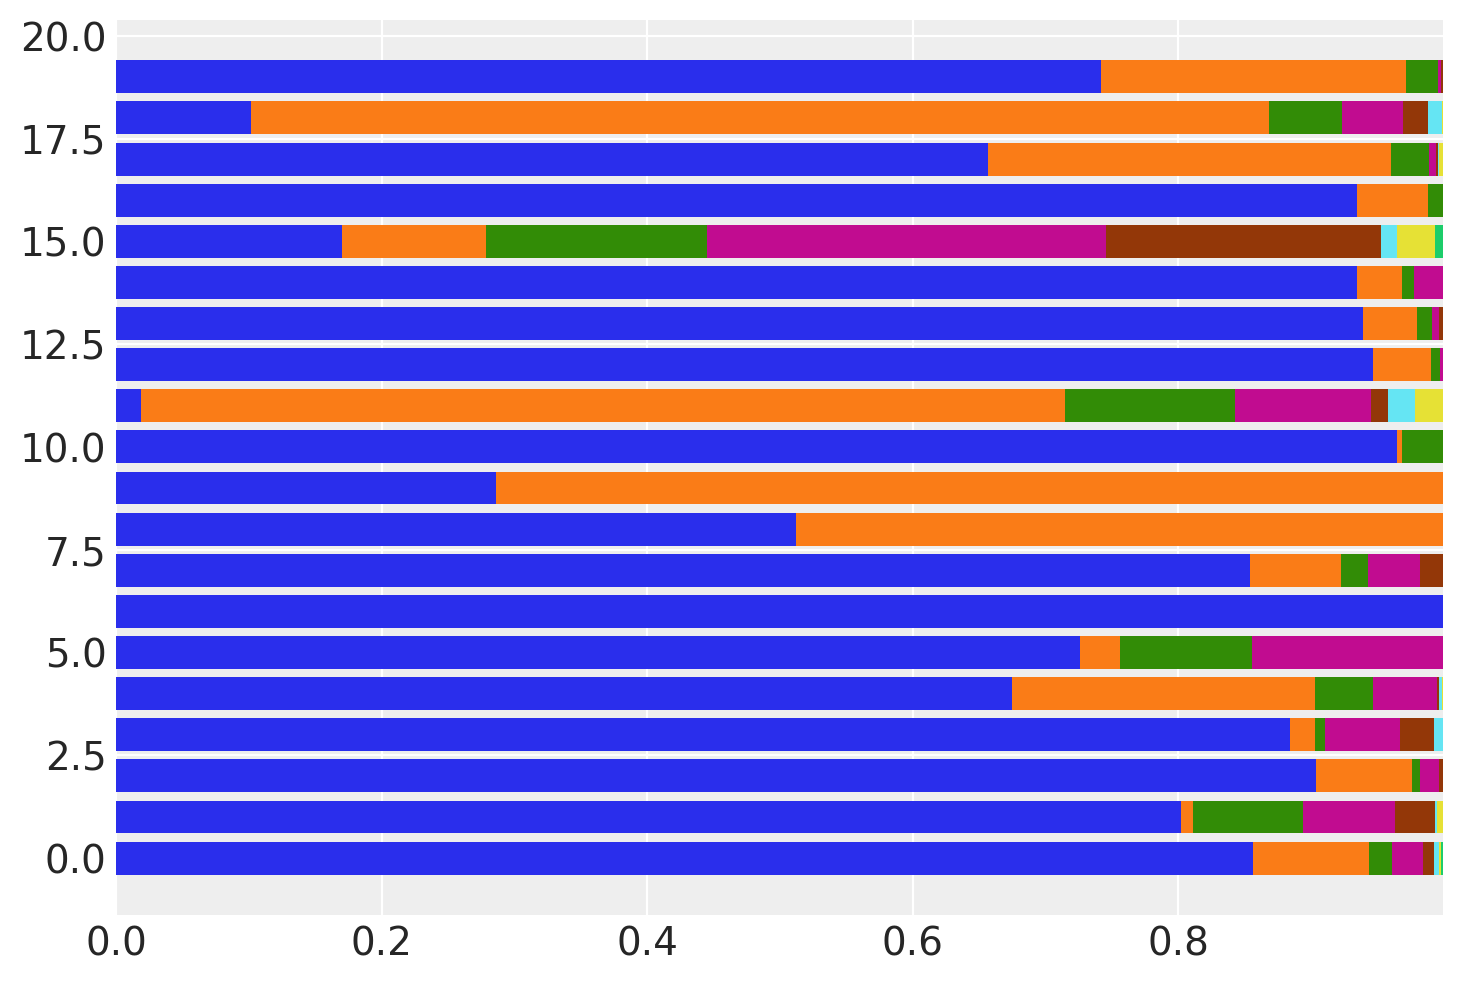

In [6]:
left = np.zeros(N)
for i in range(K):
    plt.barh(range(N), w[:, i], left=left)
    left += w[:, i]

Sample the underlying distribution -- we have $N$ different samples of the $K$ values

In [7]:
omega = P0.rvs(scale=0.5, size=(N, K))

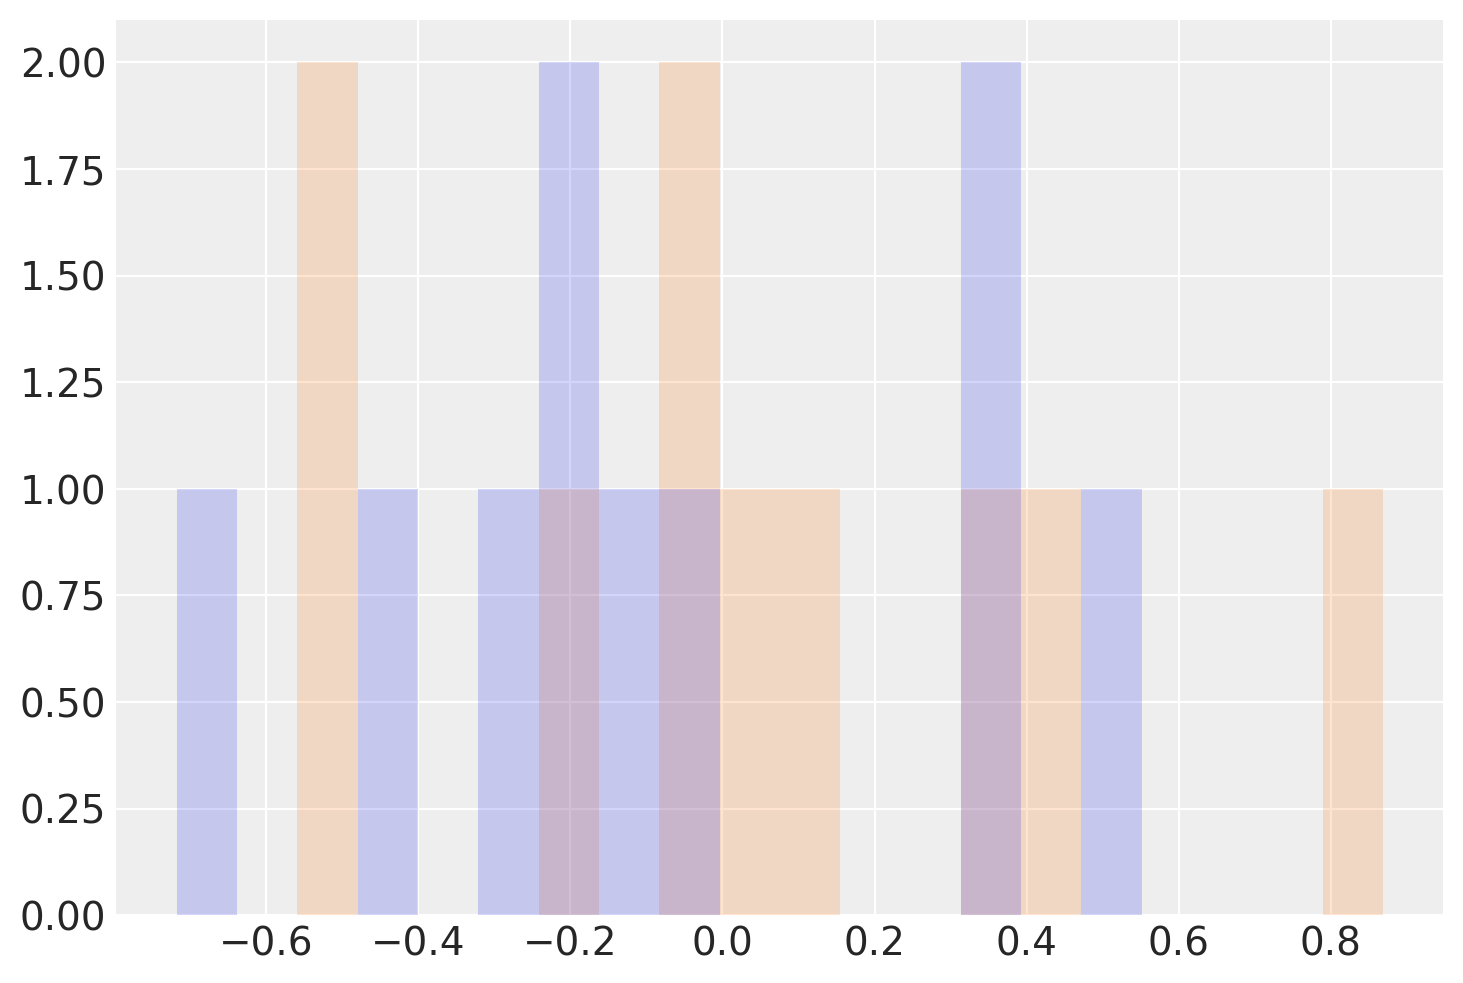

In [8]:
plt.hist(omega[:2].T, histtype='stepfilled', bins=20, alpha=0.2);

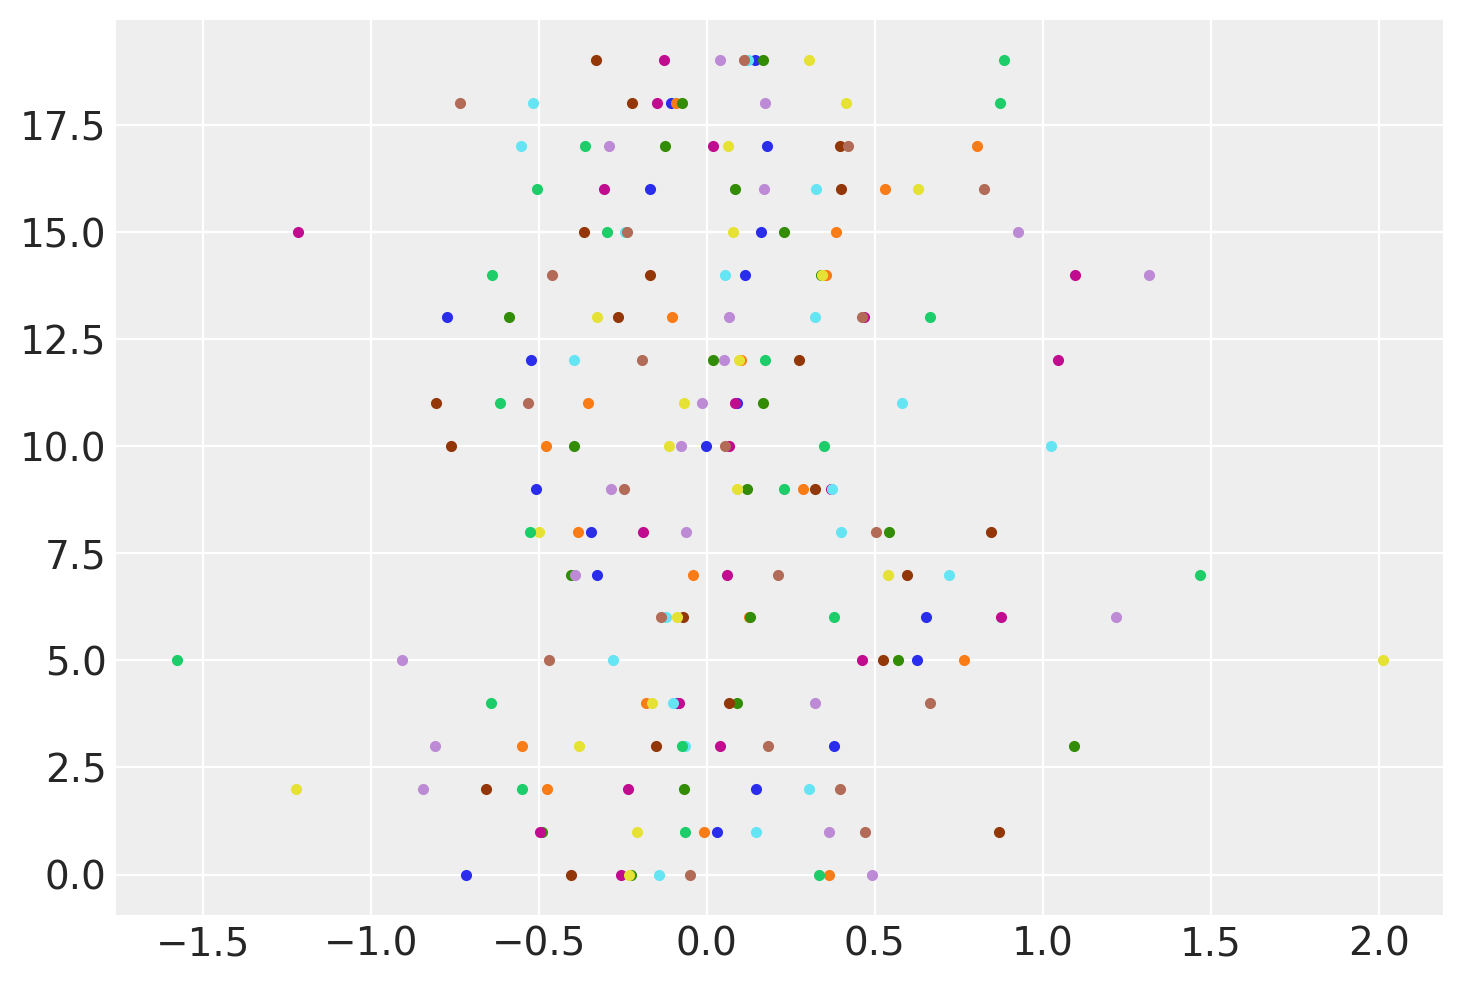

In [9]:
plt.plot(omega, range(N), marker='.', ls='none');

It's better to plot this as a cumulative distribution.  The scale of the underlying $N(0, 1)$ related to the width.  The number of different clusters/tables/sticks $K$ determines the smoothness -- if we have lots, the distribution looks smooth -- if we only have a few, it's blocky and more variable.

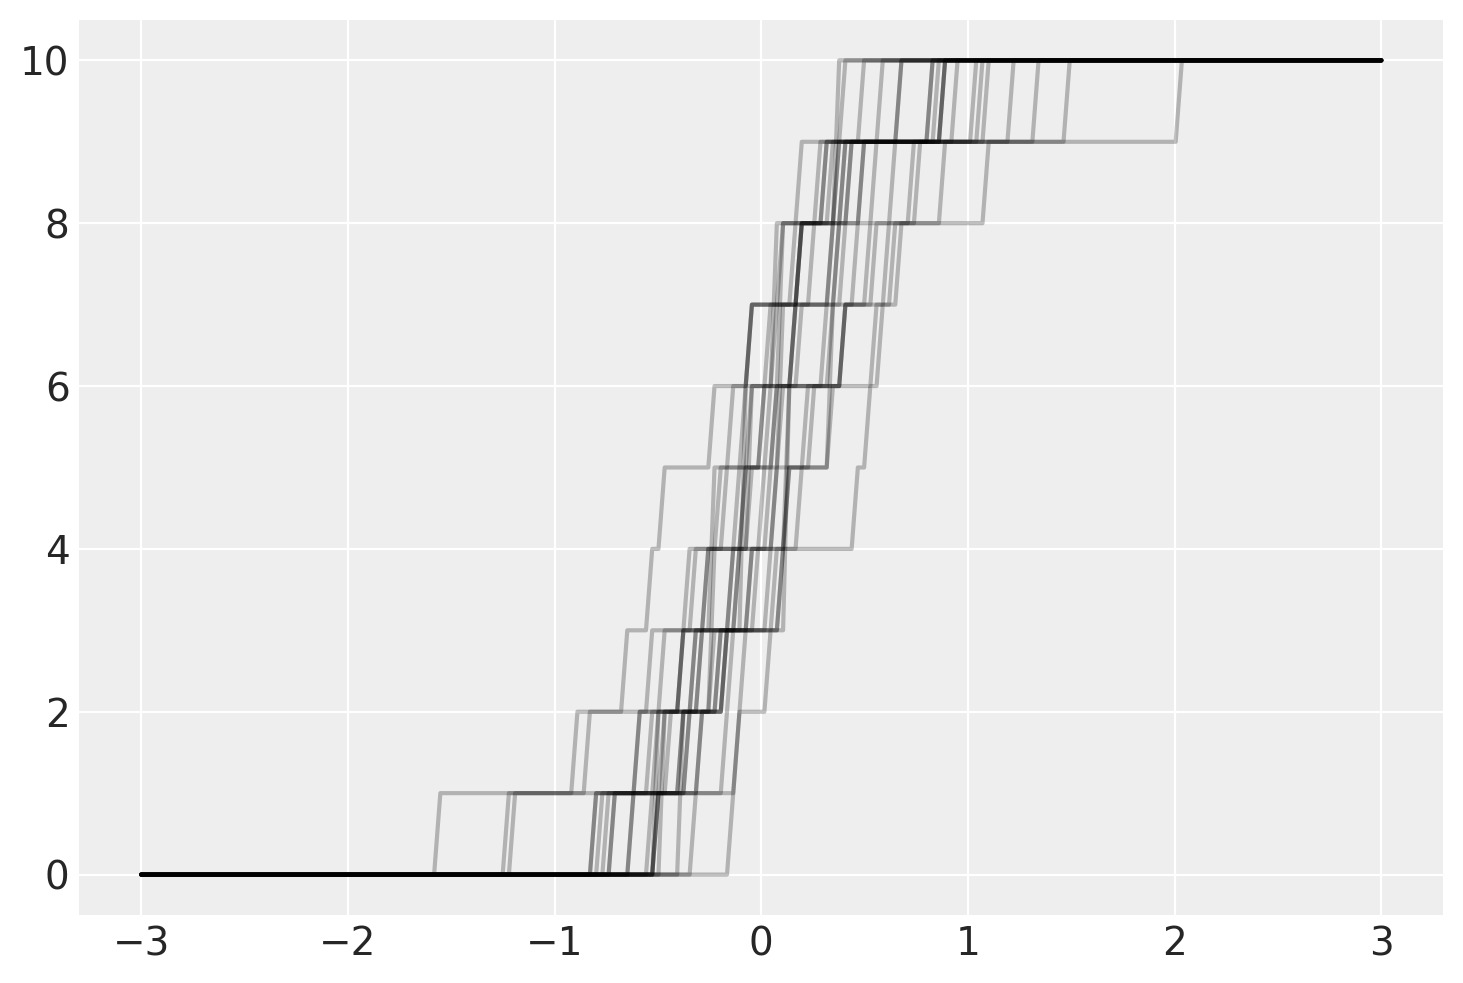

In [10]:
x_plot = xr.DataArray(np.linspace(-3, 3, 200), dims=["plot"])
omega_cdf = np.less.outer(omega, x_plot.values).sum(axis=1)
plt.plot(x_plot, omega_cdf.T, 'k', alpha=0.25);

Now assemble the sampled distribution, which only takes a subset of the sampled values according to the stick-breaking samples:

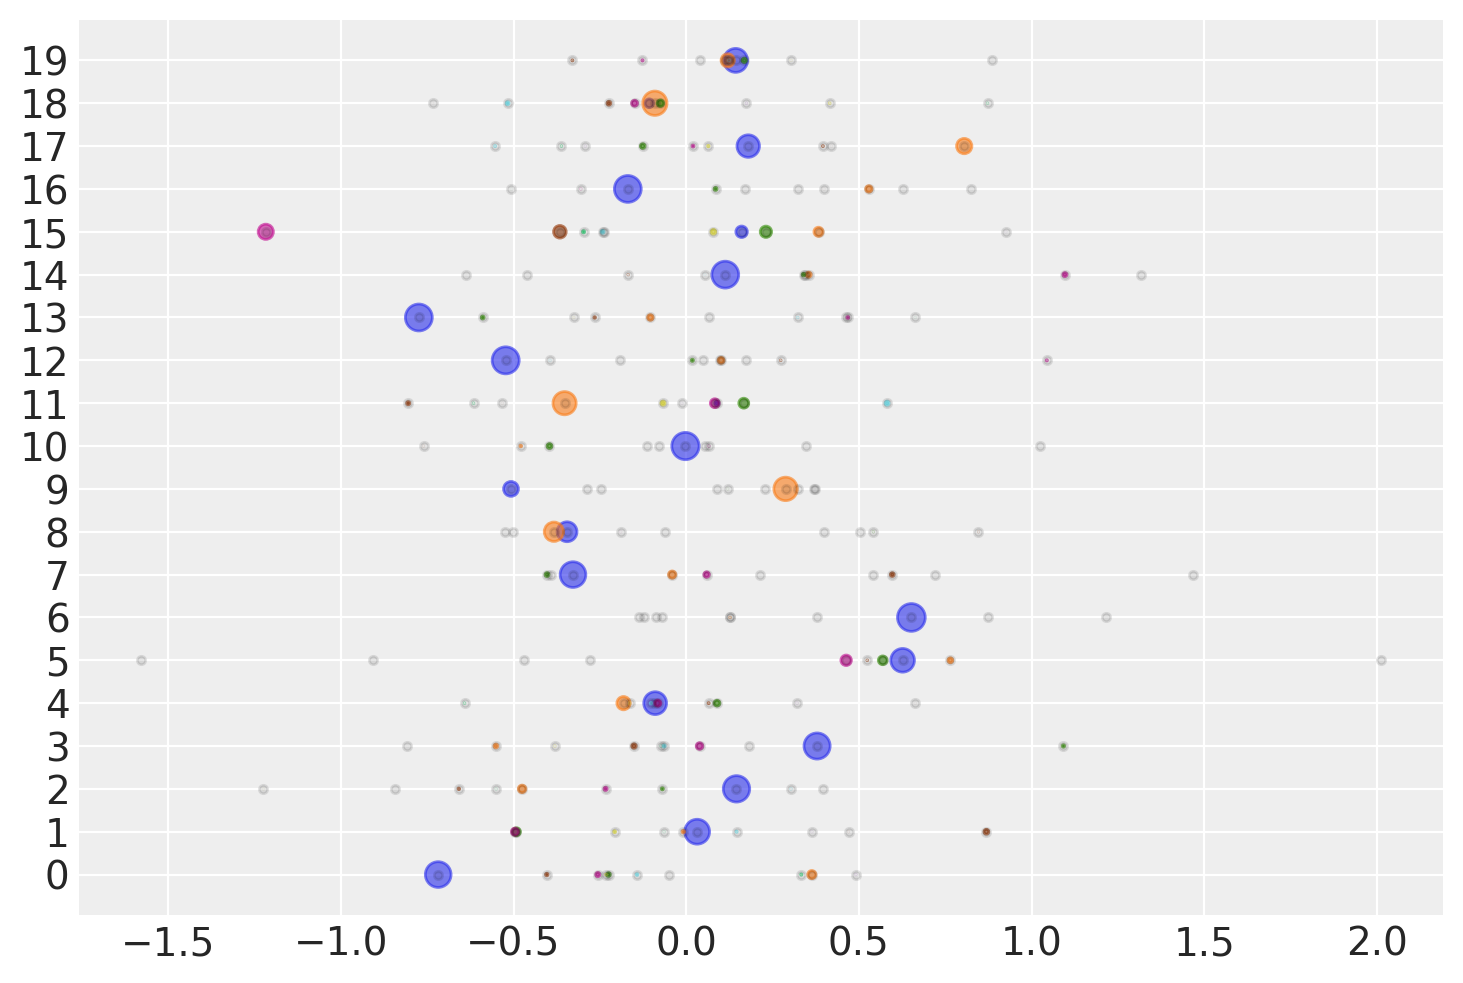

In [11]:
plt.plot(omega, range(N), marker='.', ls='none', c='k', alpha=0.1);
for i in range(K):
    plt.scatter(omega[:, i], range(N), s=w[:, i]*100, alpha=0.6);
# I don't think this mean is particularly useful or meaningful when thinking about mixture models
#for i in range(N):
#    plt.plot((omega[i] * w[i]).sum(), i, marker='|', ms=15, c='k');
plt.yticks(range(N));

In some cases, all the weight is placed on just one or two elements, which results in a jumpy CDF.  Other times, it is spread more uniformly across many.

In [12]:
sample_cdfs = (w[..., np.newaxis] * np.less.outer(omega, x_plot.values)).sum(axis=1)

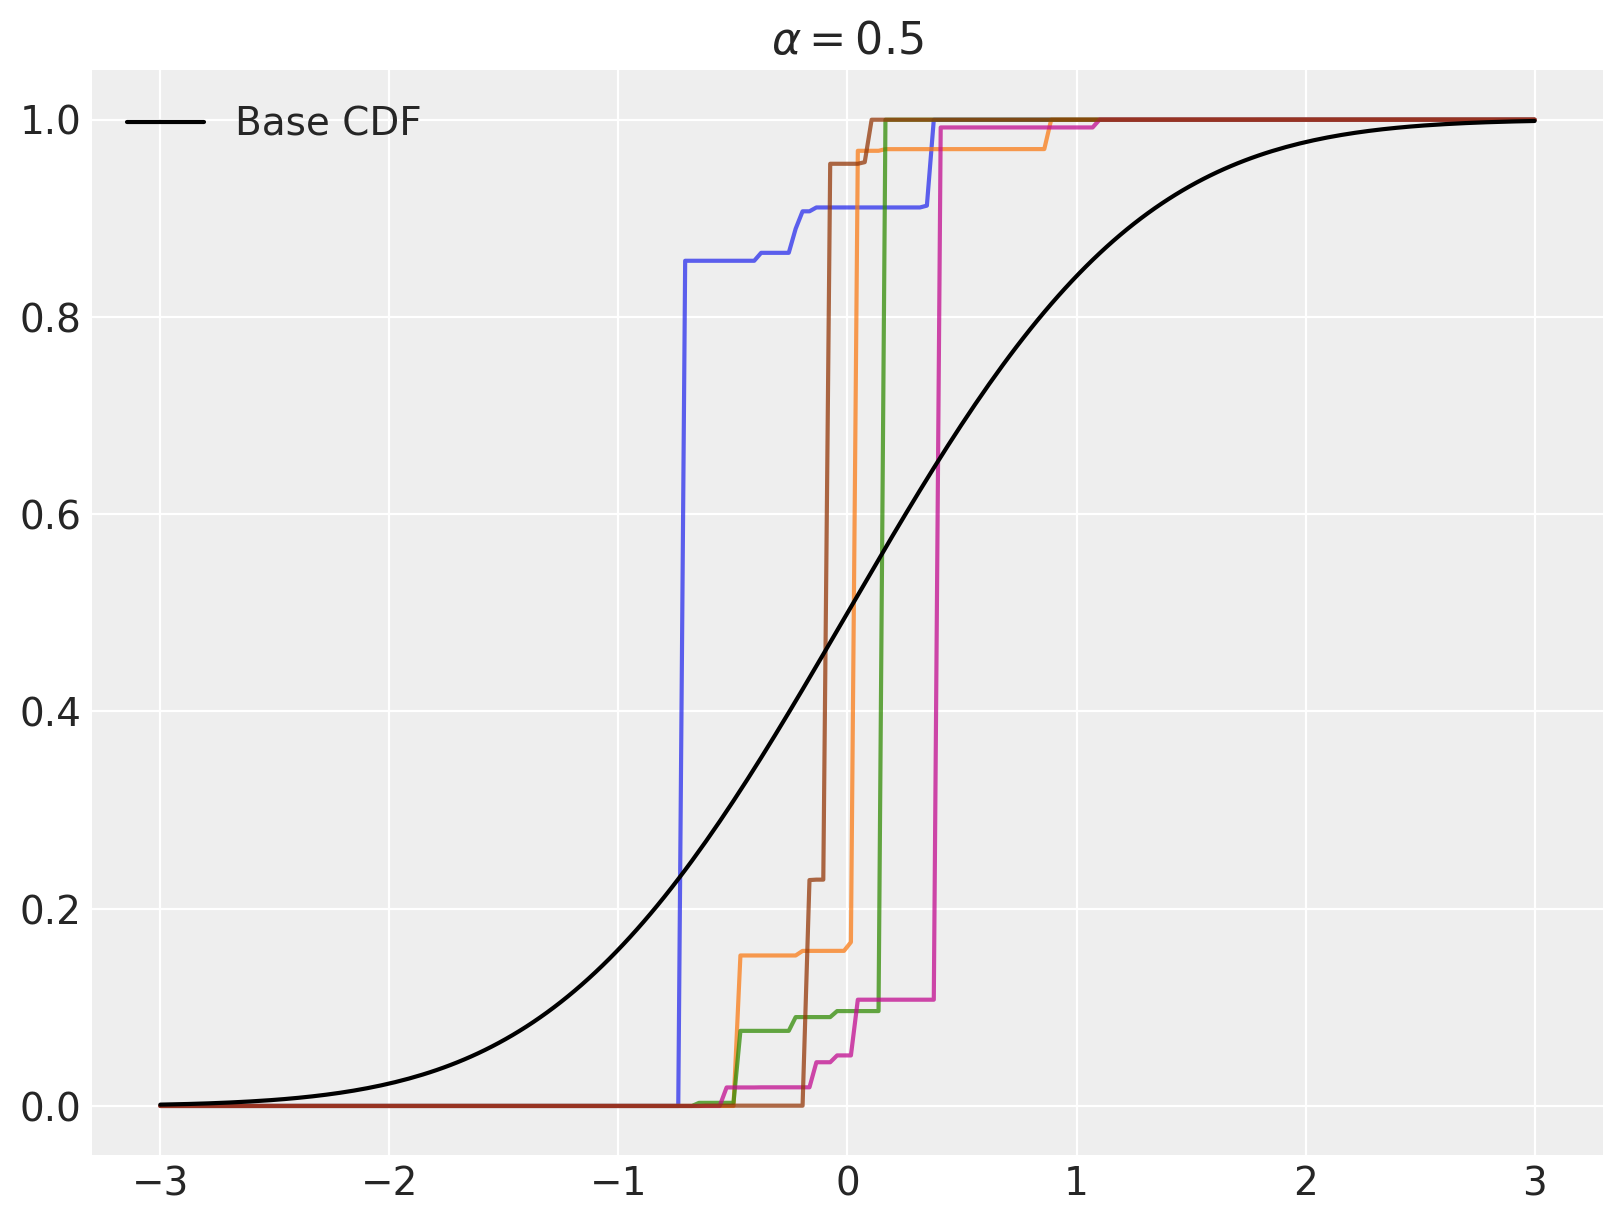

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x_plot, sample_cdfs[:5].T, alpha=0.75)
ax.plot(x_plot, P0.cdf(x_plot), c="k", label="Base CDF")

ax.set_title(rf"$\alpha = {alpha}$")
ax.legend(loc=2);

Show the same thing as a PDF rather than a CDF:

In [14]:
w[0]

array([8.56923713e-01, 8.70127089e-02, 1.76334900e-02, 2.34095619e-02,
       8.05182588e-03, 3.91282653e-03, 1.04488806e-03, 1.82561015e-03,
       1.01666172e-04, 6.87929588e-07])

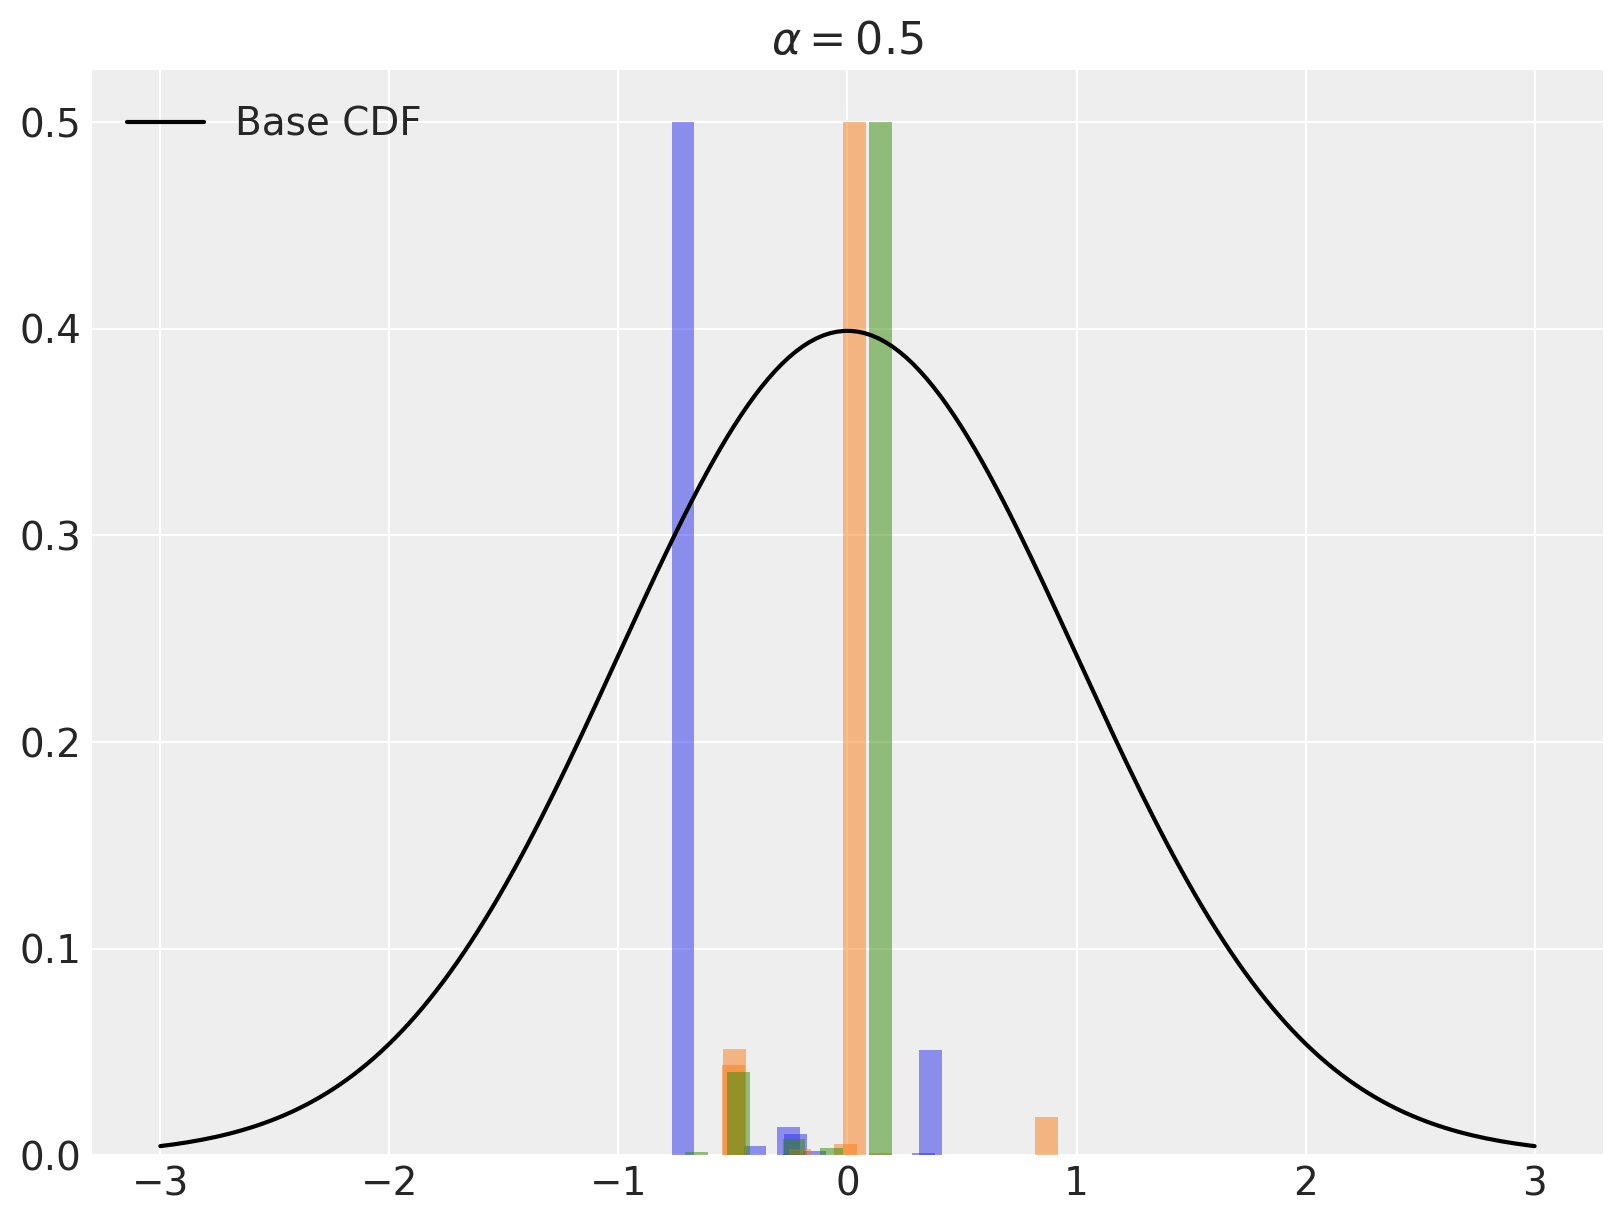

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(3):
    ax.bar(omega[i], w[i]*1/w[i].max()/2, width=1/K, alpha=0.5);
ax.plot(x_plot, P0.pdf(x_plot), c="k", label="Base CDF")

ax.set_title(rf"$\alpha = {alpha}$")
ax.legend(loc=2);

Now, adapt this to the continuous Dirichlet process *mixture* -- rather than using directly the *discrete* output of the Dirichlet process, we use it to parameterise another distribution:

In [16]:
f = lambda x, theta: sp.stats.norm.pdf(x, theta, 0.5)

# renaming?
theta = omega

dpm_pdf_components = f(x_plot, theta[..., np.newaxis])
dpm_pdfs = (w[..., np.newaxis] * dpm_pdf_components).sum(axis=1)

Look at components for each sample:

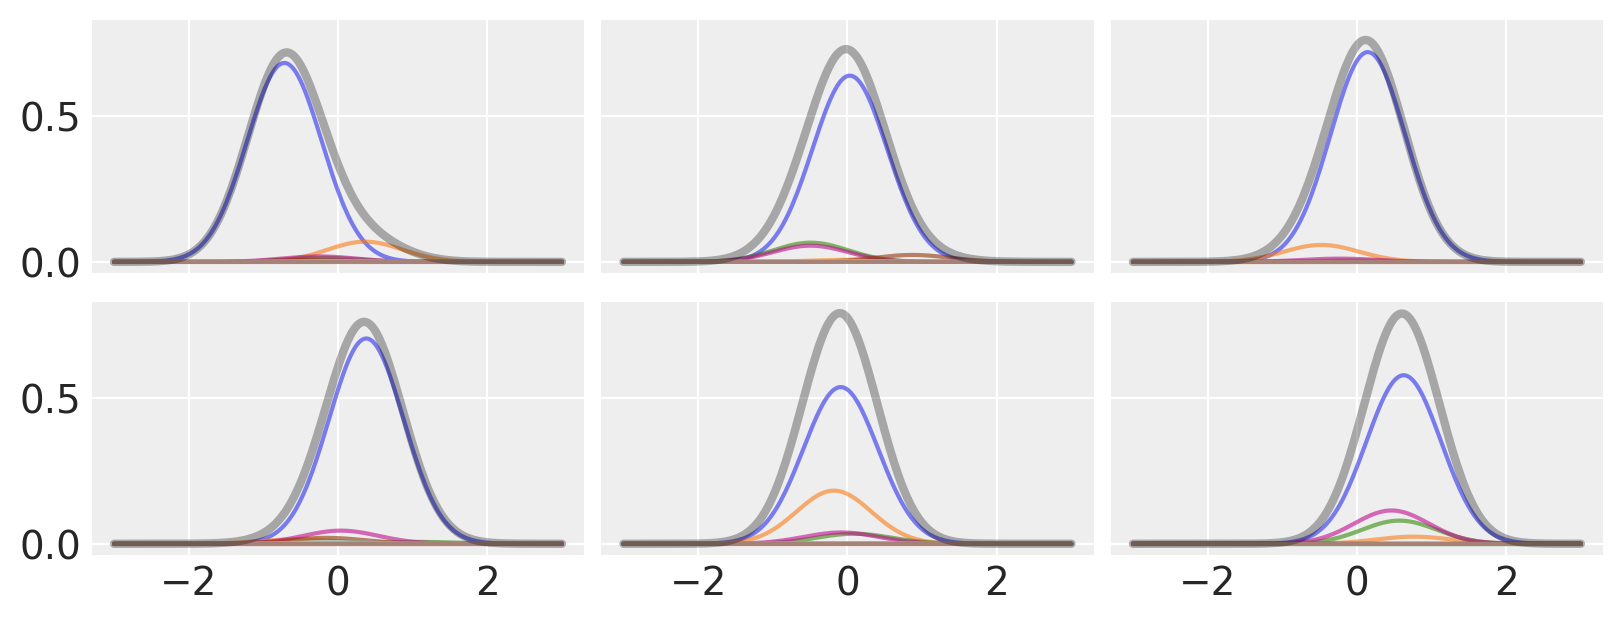

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(8, 3), sharex=True, sharey=True)
for i in range(6):
    ax.flat[i].plot(x_plot, w[i] * dpm_pdf_components[i].T, alpha=0.6);
    ax.flat[i].plot(x_plot, dpm_pdfs[i], c='k', lw=3, alpha=0.3);

The original Dirichlet process samples are being used as the means of these distributions -- here, we have assumed a fixed width.

The difference is that:
- Before, the distribution was constructed from the discrete sampled points -- giving a lumpy histogram, or a stepped CDF
- Now, the distribution is constructed as a continuous function around each sampled point
- As the bandwidth gets very small, they become more similar?

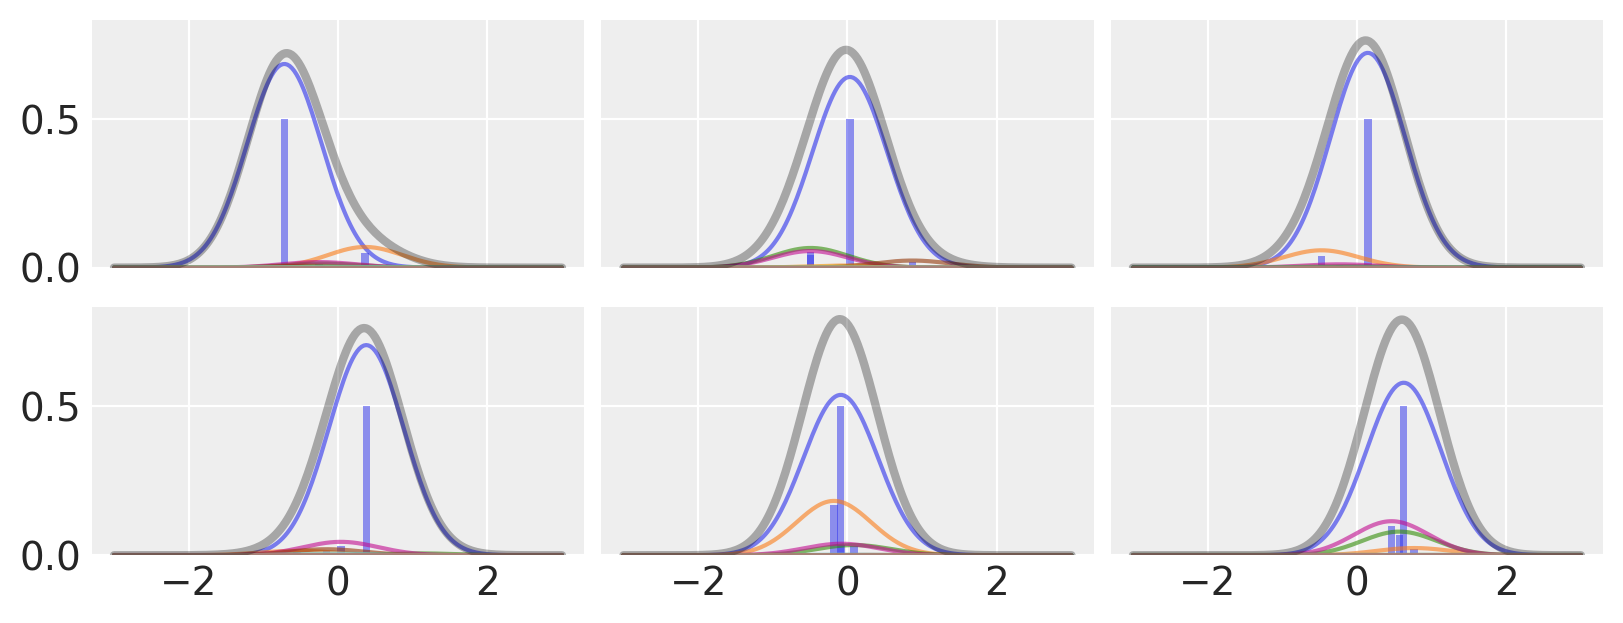

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(8, 3), sharex=True, sharey=True)
for i in range(6):
    ax.flat[i].plot(x_plot, w[i] * dpm_pdf_components[i].T, alpha=0.6);
    ax.flat[i].plot(x_plot, dpm_pdfs[i], c='k', lw=3, alpha=0.3);
    ax.flat[i].bar(omega[i], w[i]*1/w[i].max()/2, width=1/K, alpha=0.5);

## Old Faithful example


In [19]:
import pymc as pm
import pytensor.tensor as pt

In [20]:
old_faithful_df = pd.read_csv(pm.get_data("old_faithful.csv"))
old_faithful_df["std_waiting"] = (
    old_faithful_df.waiting - old_faithful_df.waiting.mean()
) / old_faithful_df.waiting.std()

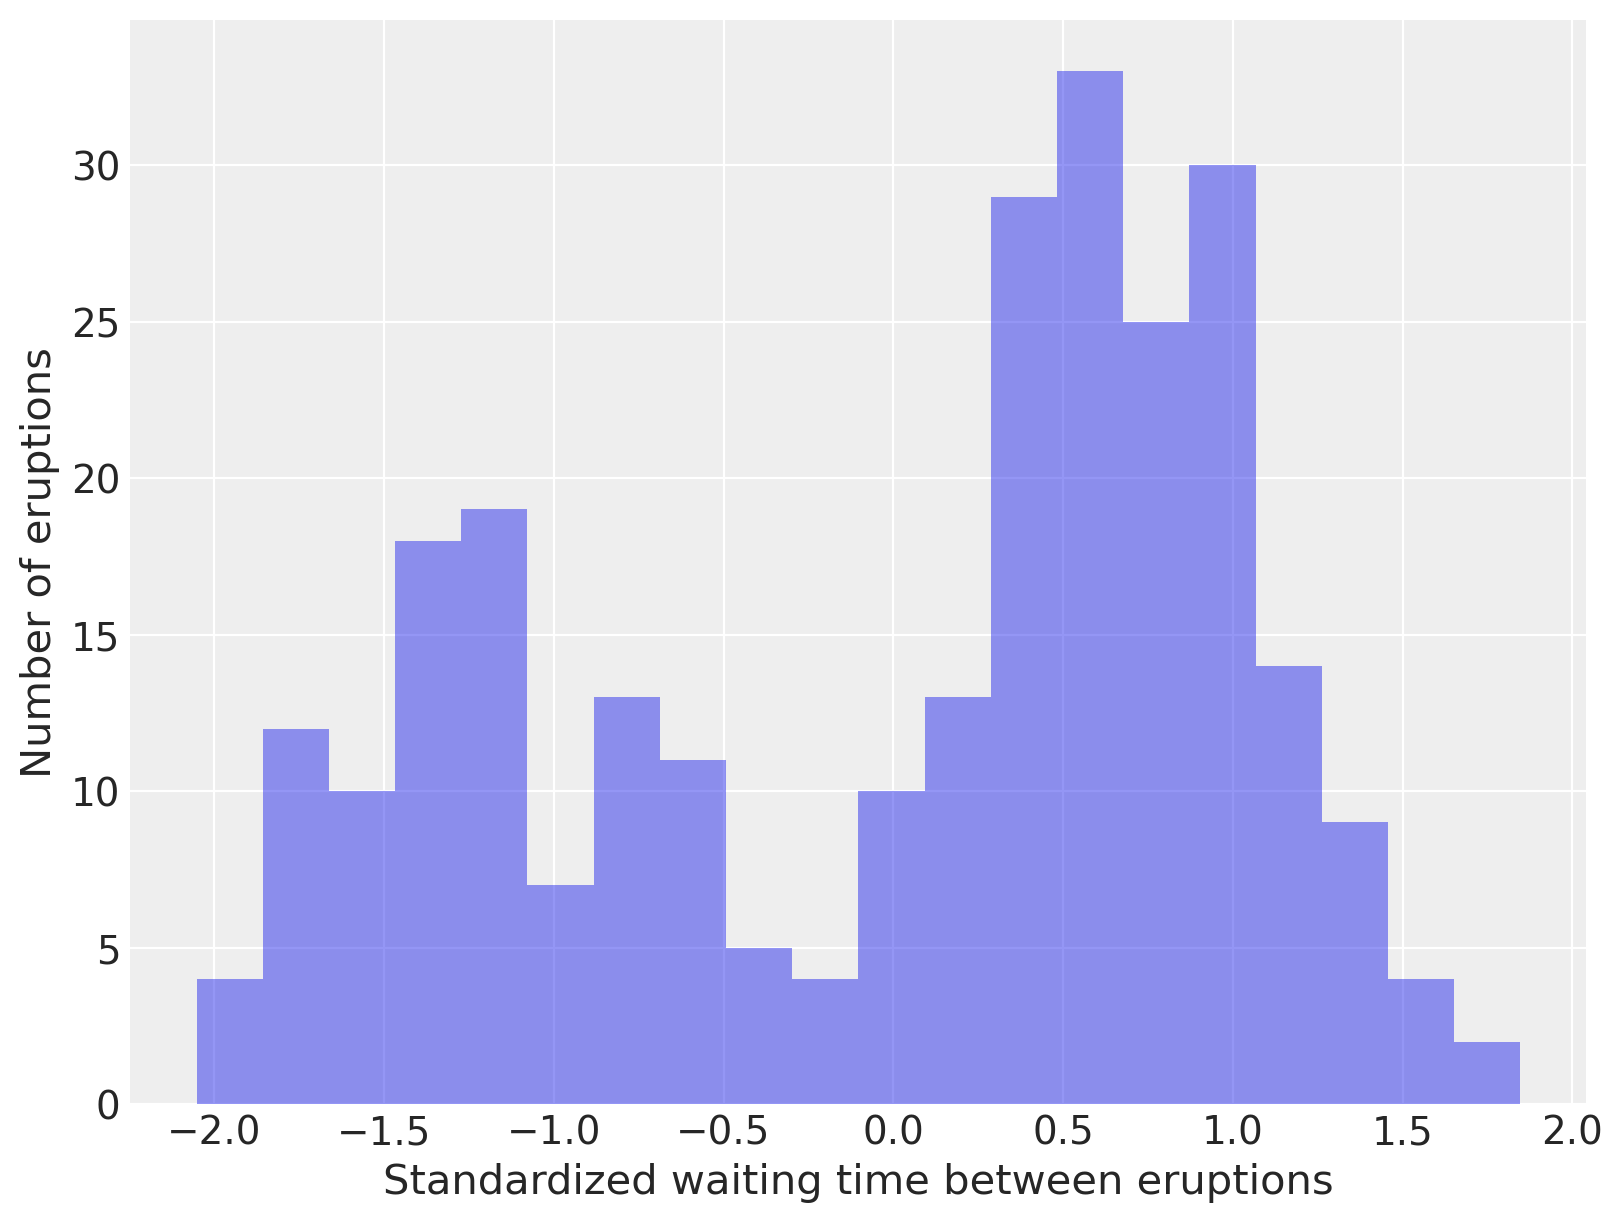

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting, bins=n_bins, color="C0", lw=0, alpha=0.5)

ax.set_xlabel("Standardized waiting time between eruptions")
ax.set_ylabel("Number of eruptions");

In [22]:
N = old_faithful_df.shape[0]
K = 30

In [23]:
def stick_breaking(beta):
    portion_remaining = pt.concatenate([[1], pt.extra_ops.cumprod(1 - beta)[:-1]])
    return beta * portion_remaining

In [24]:
with pm.Model(coords={"component": np.arange(K), "obs_id": np.arange(N)}) as model:
    # Prior on alpha (number of components) -- we don't know how concentrated it should be
    alpha = pm.Gamma("alpha", 1.0, 1.0)

    # Stick-breaking calculation
    beta = pm.Beta("beta", 1.0, alpha, dims="component")
    w = pm.Deterministic("w", stick_breaking(beta), dims="component")

    # Prior on tau, related to concentration of components
    # Prior on lambda_, ont sure why we need this?
    tau = pm.Gamma("tau", 1.0, 1.0, dims="component")
    lambda_ = pm.Gamma("lambda_", 10.0, 1.0, dims="component")

    # Base distribution -- why does this also depend on tau and lambda?
    # I suppose wider distributions need a wider range of mean values?
    mu = pm.Normal("mu", 0, tau=lambda_ * tau, dims="component")

    # Final mixture, where each component has precision lambda*tau, 
    # and samples from the components reflect the observed data
    obs = pm.NormalMixture(
        "obs", w, mu, tau=lambda_ * tau, observed=old_faithful_df.std_waiting.values, dims="obs_id"
    )

In [25]:
with model:
    trace = pm.sample(
        tune=2500,
        init="advi",
        target_accept=0.975,
        random_seed=RANDOM_SEED,
    )

Auto-assigning NUTS sampler...
Initializing NUTS using advi...


Output()

Convergence achieved at 10800
Interrupted at 10,799 [5%]: Average Loss = 489.35
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, tau, lambda_, mu]


Output()

Sampling 4 chains for 2_500 tune and 1_000 draw iterations (10_000 + 4_000 draws total) took 667 seconds.
There were 114 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


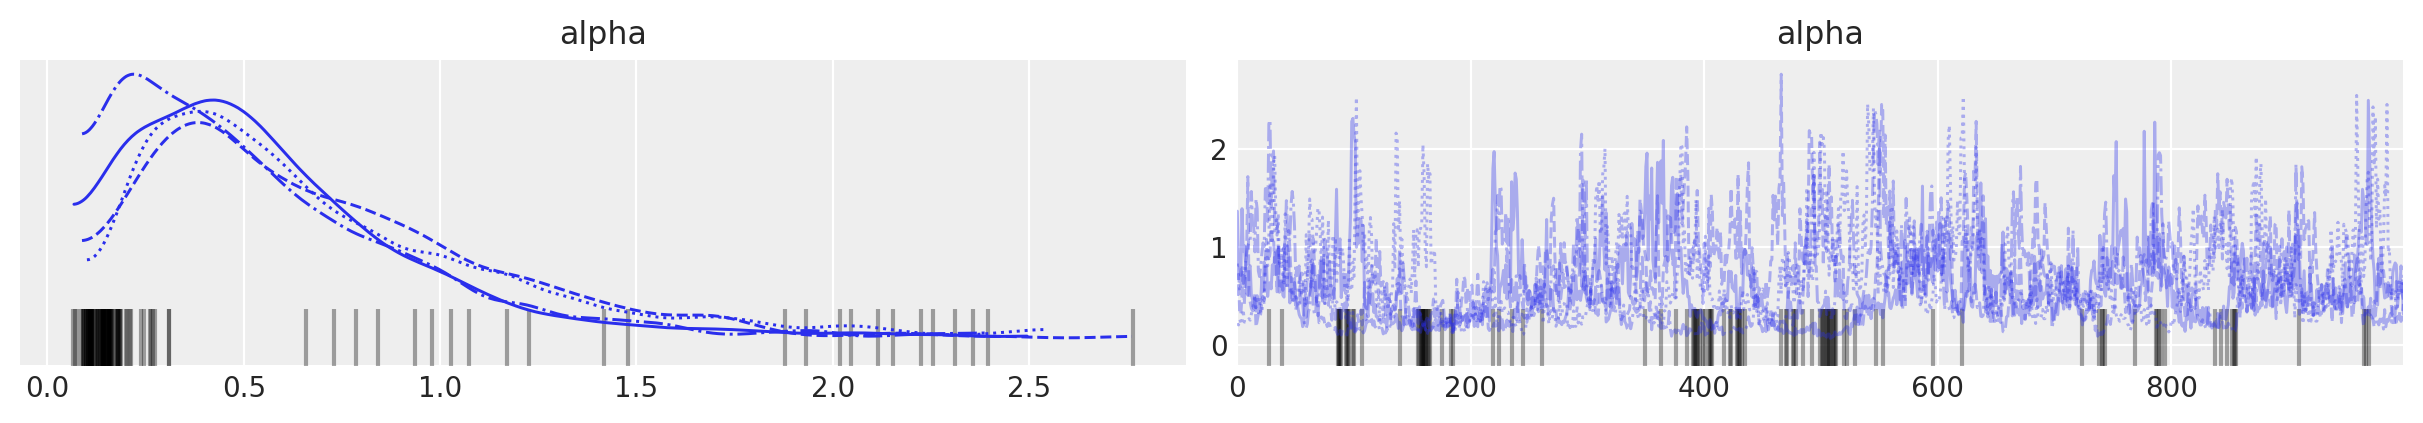

In [26]:
az.plot_trace(trace, var_names=["alpha"]);

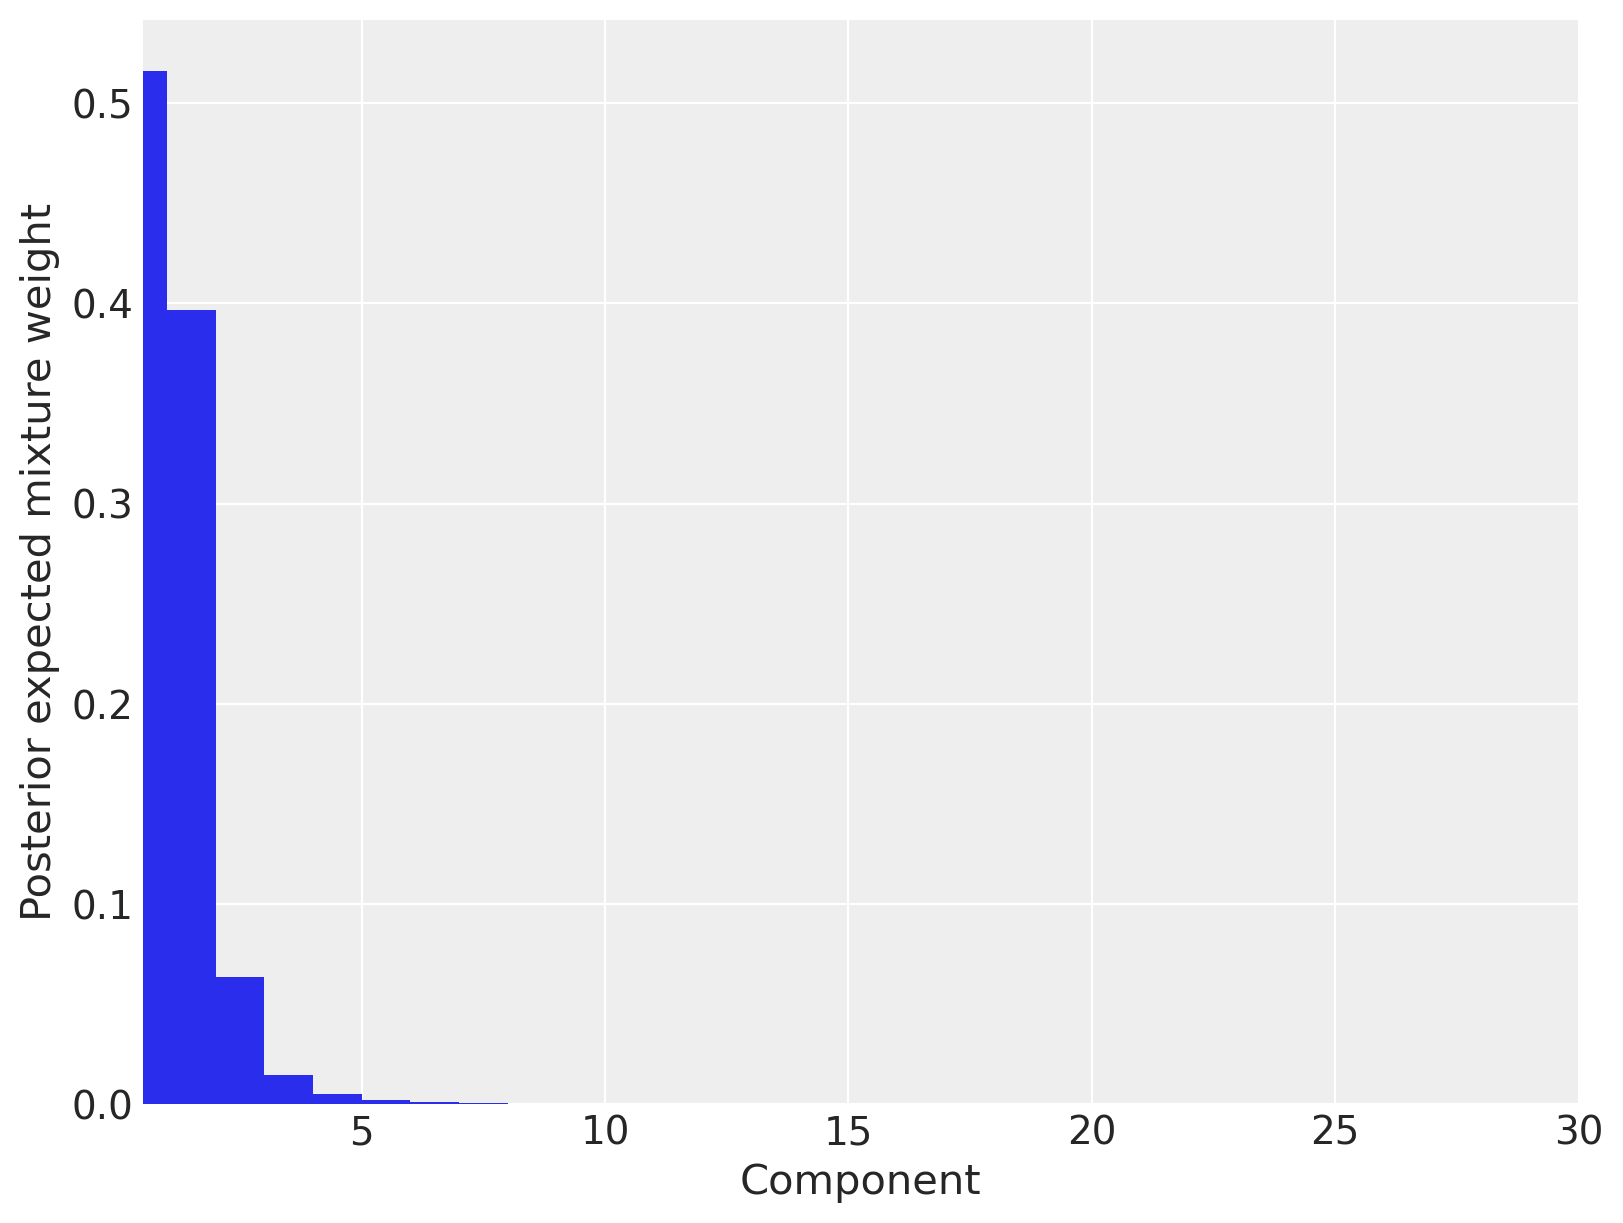

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_w = np.arange(K) + 1

ax.bar(plot_w - 0.5, trace.posterior["w"].mean(("chain", "draw")), width=1.0, lw=0)

ax.set_xlim(0.5, K)
ax.set_xlabel("Component")

ax.set_ylabel("Posterior expected mixture weight");

In [28]:
post_pdf_contribs = xr.apply_ufunc(
    sp.stats.norm.pdf,
    x_plot,
    trace.posterior["mu"],
    1.0 / np.sqrt(trace.posterior["lambda_"] * trace.posterior["tau"]),
)

post_pdfs = (trace.posterior["w"] * post_pdf_contribs).sum(dim=("component"))

post_pdf_quantiles = post_pdfs.quantile([0.1, 0.9], dim=("chain", "draw"))

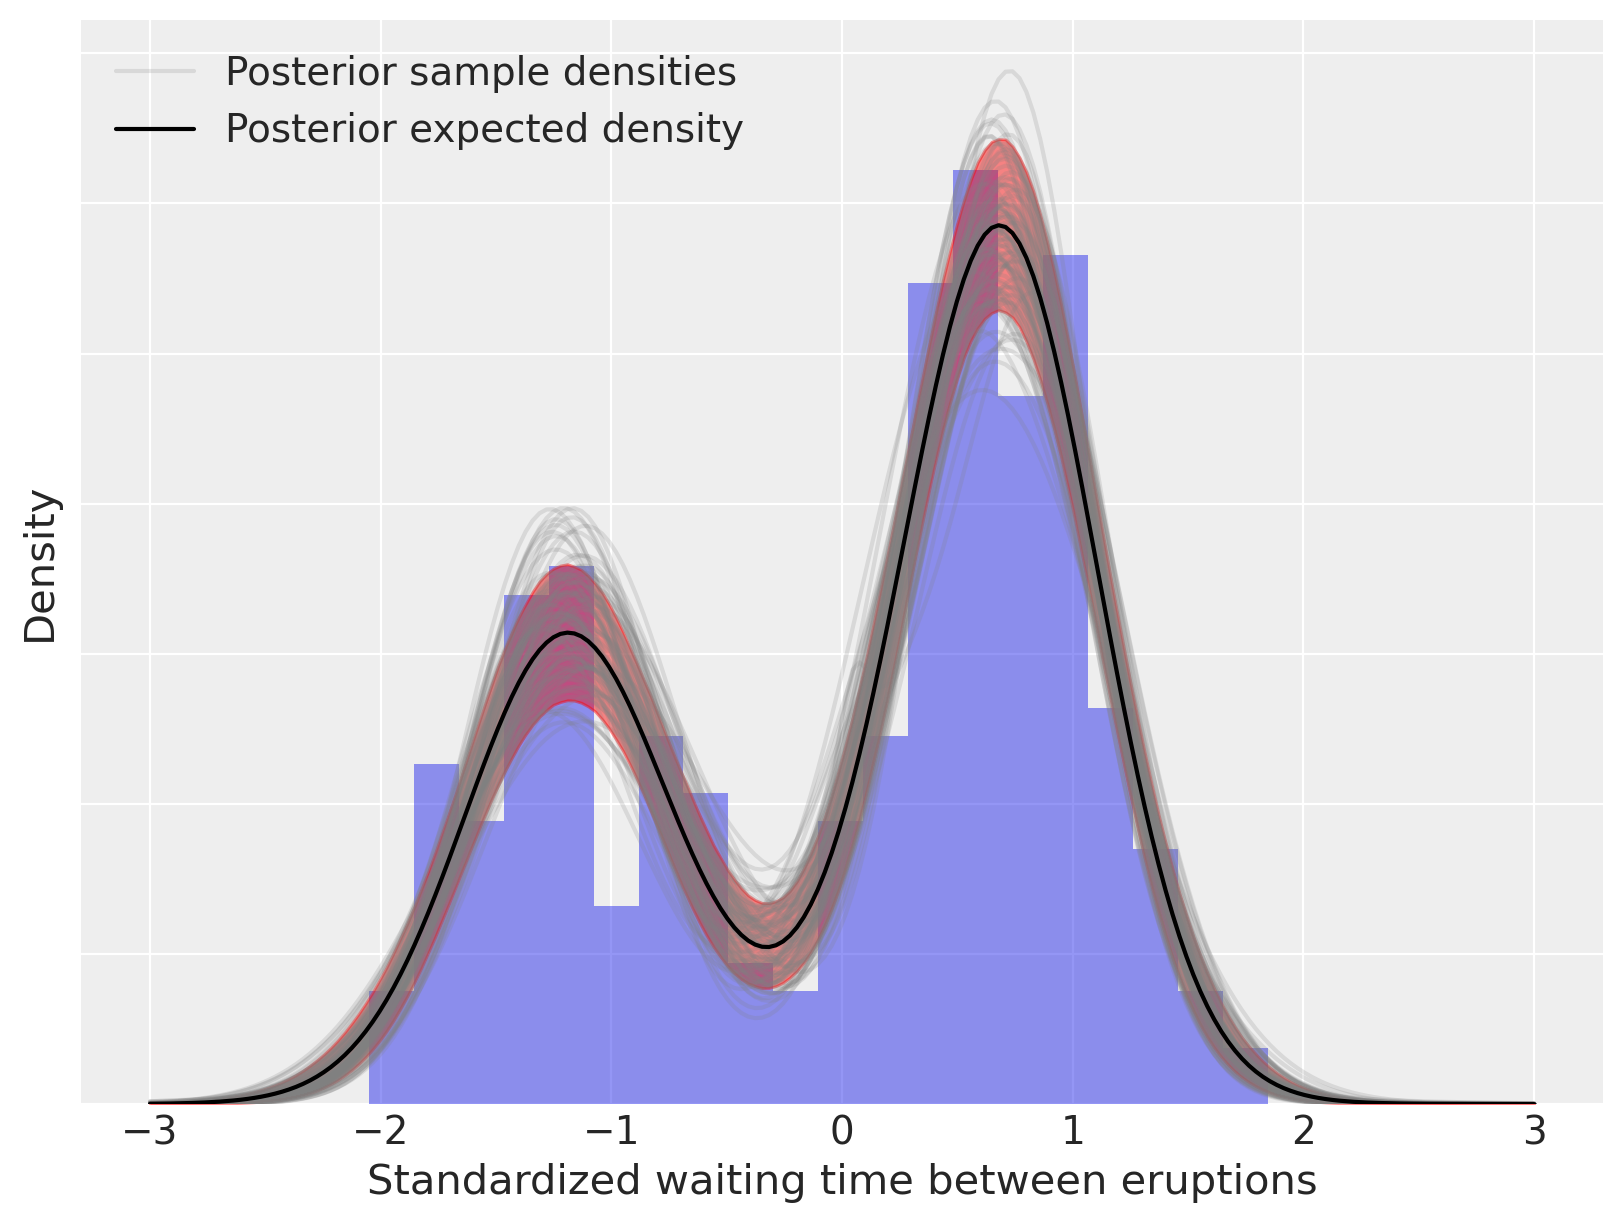

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

n_bins = 20
ax.hist(old_faithful_df.std_waiting.values, bins=n_bins, density=True, color="C0", lw=0, alpha=0.5)

ax.fill_between(
    x_plot,
    post_pdf_quantiles.sel(quantile=0.1),
    post_pdf_quantiles.sel(quantile=0.9),
    color="red",
    alpha=0.45,
)
ax.plot(x_plot, post_pdfs.sel(chain=0, draw=0), c="gray", alpha=0.2, label="Posterior sample densities")
ax.plot(
    x_plot,
    az.extract(post_pdfs, var_names="x", num_samples=100),
    c="gray",
    alpha=0.2,
)
ax.plot(x_plot, post_pdfs.mean(dim=("chain", "draw")), c="k", label="Posterior expected density")

ax.set_xlabel("Standardized waiting time between eruptions")

ax.set_yticklabels([])
ax.set_ylabel("Density")

ax.legend(loc=2);

In [30]:
with model:
    trace_ppd = pm.sample_posterior_predictive(trace)

Sampling: [obs]


Output()

<Axes: xlabel='obs'>

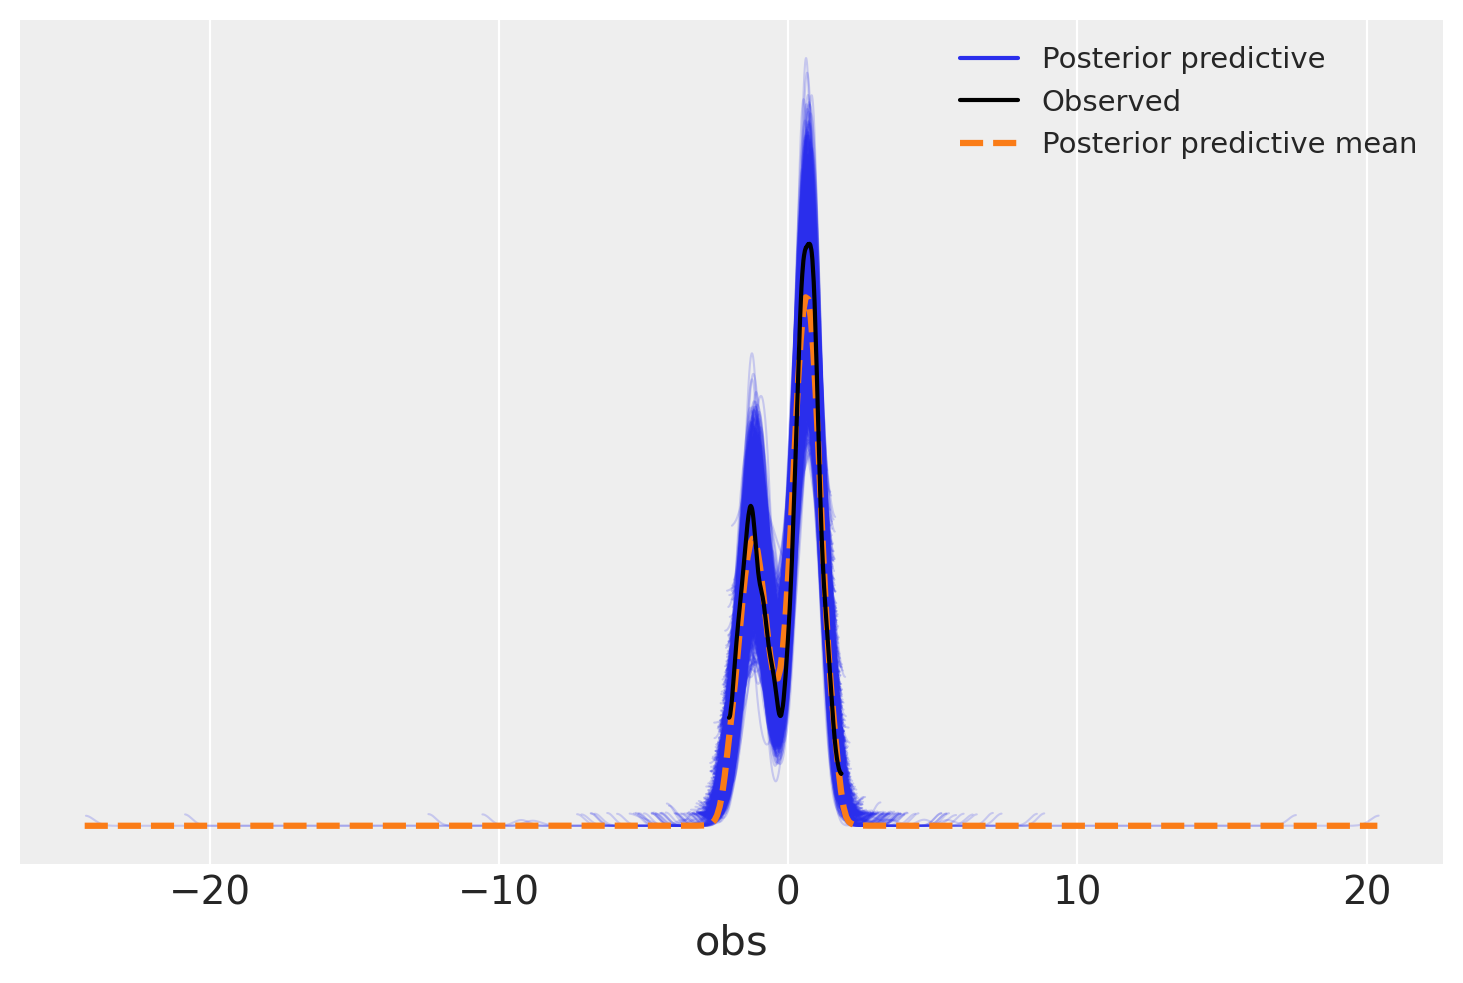

In [31]:
az.plot_ppc(trace_ppd)

In [32]:
trace_ppd.posterior_predictive.obs

<xarray.DataArray 'obs' (chain: 4, draw: 1000, obs_id: 272)> Size: 9MB
array([[[-0.60361285,  0.85184915,  0.77930524, ...,  0.54102911,
          0.35943064, -1.23012735],
        [-0.31625392, -0.66509748,  0.71082539, ..., -1.84582875,
          0.70555499,  1.41233234],
        [ 0.33640465, -1.39354198,  0.43607079, ...,  1.35244877,
         -1.64592536,  0.57408219],
        ...,
        [ 1.41518871,  1.32815316, -0.36094248, ...,  0.50747594,
          1.34754656,  0.22758835],
        [-0.11547804,  0.25461862,  0.56208375, ..., -1.01601604,
          1.01811053,  0.67166324],
        [-1.21055018,  0.69325318,  0.55234446, ..., -0.52686041,
          0.65659839,  1.0087915 ]],

       [[ 1.00422552,  0.97985959, -1.32309527, ...,  0.96554746,
         -0.86463748,  0.38463679],
        [ 0.96584881,  0.45237729,  0.80798744, ...,  0.54683514,
         -0.03322146,  0.71274098],
        [ 0.53576827, -1.67959838, -1.32493754, ...,  1.68357063,
          0.56441048, -2.00394841],
...
        [ 0.47170107,  0.6459987 ,  0.44816673, ..., -1.23378561,
          0.46132095,  0.99539969],
        [ 0.29602241,  1.3012874 ,  1.0303283 , ..., -1.65547   ,
         -0.32111026, -1.95205583],
        [ 0.32739264,  0.81427745,  1.78644646, ...,  0.18179507,
          0.7694662 ,  0.25208111]],

       [[-1.18245414,  1.02374786,  0.77030383, ..., -0.09875104,
          1.21787475,  1.14170248],
        [ 0.94822771,  0.86301891, -0.54711382, ..., -0.40690494,
          0.9180284 ,  1.18503779],
        [ 0.19938127,  0.38112276,  1.01075919, ..., -0.9425416 ,
          1.1544005 , -1.2792991 ],
        ...,
        [-0.06832437,  0.81381843, -0.85276532, ..., -0.83355754,
         -1.24129024,  1.16222048],
        [-1.17889571,  0.912785  ,  1.45940727, ..., -1.08977106,
         -0.79096094,  1.37540366],
        [-1.40278264,  0.32515264, -1.28352467, ..., -0.61270923,
         -0.05689578, -0.08409368]]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * obs_id   (obs_id) int64 2kB 0 1 2 3 4 5 6 7 ... 265 266 267 268 269 270 271